In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import date, datetime, timedelta
import kagglehub

/Users/hanhnh1002/miniforge3/envs/credit_app/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


> ## 1. Data preparation

In [3]:
# Download latest version
path = kagglehub.dataset_download("tranhuunhan/vietnam-bank-churn-dataset-2025")
print("Path to dataset files:", path)
csv_file = os.listdir(path)[0]
print(csv_file)
full_path = os.path.join(path, csv_file)
print(full_path)

Path to dataset files: /Users/hanhnh1002/.cache/kagglehub/datasets/tranhuunhan/vietnam-bank-churn-dataset-2025/versions/1
bank_churn_dataset_80k.csv
/Users/hanhnh1002/.cache/kagglehub/datasets/tranhuunhan/vietnam-bank-churn-dataset-2025/versions/1/bank_churn_dataset_80k.csv


In [4]:
pd.set_option('display.max_columns', None)
df = pd.read_csv(full_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      80000 non-null  int64  
 1   full_name               80000 non-null  object 
 2   credit_sco              80000 non-null  int64  
 3   gender                  80000 non-null  object 
 4   age                     80000 non-null  int64  
 5   occupation              80000 non-null  object 
 6   balance                 80000 non-null  int64  
 7   monthly_ir              80000 non-null  int64  
 8   address                 80000 non-null  object 
 9   origin_province         80000 non-null  object 
 10  tenure_ye               80000 non-null  int64  
 11  married                 80000 non-null  int64  
 12  nums_card               80000 non-null  int64  
 13  nums_service            80000 non-null  int64  
 14  active_member           80000 non-null

In [5]:
print( 'Dataset has no null value? :', (df.isna().sum() == 0).all())

Dataset has no null value? : True


In [6]:
df = df.set_index('id')
drop_cols = ['full_name', 'address', 'occupation', 'origin_province', 'cluster_group', 'married']
df = df.drop(columns = drop_cols, axis = 1)
df.head()

,credit_sco,gender,age,balance,monthly_ir,tenure_ye,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment
id,,,,,,,,,,,,,,,,,,,
1,725,male,55,177306004,121000000,0,4,8,True,03/04/2025,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low
2,689,male,45,1927416,5000000,3,3,2,True,14/05/2025,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low
3,702,female,44,304931745,109000000,4,2,8,False,10/09/2021,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low
4,766,male,44,50615501,79000000,3,4,3,False,04/03/2025,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low
5,677,female,77,40532432,25000000,2,4,3,False,06/08/2022,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low


#### ***Convert data type***

In [7]:
# Boolean to integer

bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [8]:
# Date string to integer

df['days_since_last_active'] = (pd.Timestamp.today() - pd.to_datetime(df['last_active_date'], format = '%d/%m/%Y')).dt.days
df['days_since_created'] = (pd.Timestamp.today() - pd.to_datetime(df['created_date'], format = '%d/%m/%Y')).dt.days
df = df.drop(columns = ['last_active_date', 'created_date'])

In [9]:
# Target columns

df['risk_segment'] = df['risk_segment'].map({'Low': 0, 'Medium':1})

#### ***Data encoding***

In [10]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ['loyalty_level', 'customer_segment']
binary_cols = ['gender', 'digital_behavior']

ordinal_encoder = OrdinalEncoder(categories=[['Bronze', 'Silver', 'Gold'], 
                                            ['Mass', 'Emerging', 'Priority', 'Affluent']])

binary_encoder = OrdinalEncoder() 

df[ordinal_cols] = ordinal_encoder.fit_transform(df[ordinal_cols])
df[binary_cols] = binary_encoder.fit_transform(df[binary_cols])


In [11]:
df.sample(5)

,credit_sco,gender,age,balance,monthly_ir,tenure_ye,nums_card,nums_service,active_member,last_transaction_month,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,days_since_last_active,days_since_created
id,,,,,,,,,,,,,,,,,,,
54697,738,1.0,53,188714057,89000000,0,5,8,1,45216902,0,2.0,90,0.0,0.0,0.0351,0,273,360
33,739,0.0,38,55318135,134000000,1,2,1,0,0,0,2.0,10,0.0,1.0,0.2424,0,361,823
58925,800,1.0,82,47081979,54000000,3,3,8,0,0,0,3.0,39,1.0,1.0,0.1569,0,1153,1483
69062,623,0.0,45,36760297,14000000,2,2,3,0,0,1,0.0,17,0.0,1.0,0.3714,0,743,1091
76286,685,0.0,54,138897140,60000000,1,4,4,0,0,0,2.0,27,0.0,1.0,0.2088,0,470,955


In [12]:
print( 'All variables are numeric? :' , (len(df.select_dtypes(include='number').columns) - len(df.columns)) == 0)

All variables are numeric? : True


#### ***Correlation***

Text(0.5, 1.0, 'Covariance Heatmap of X_train')

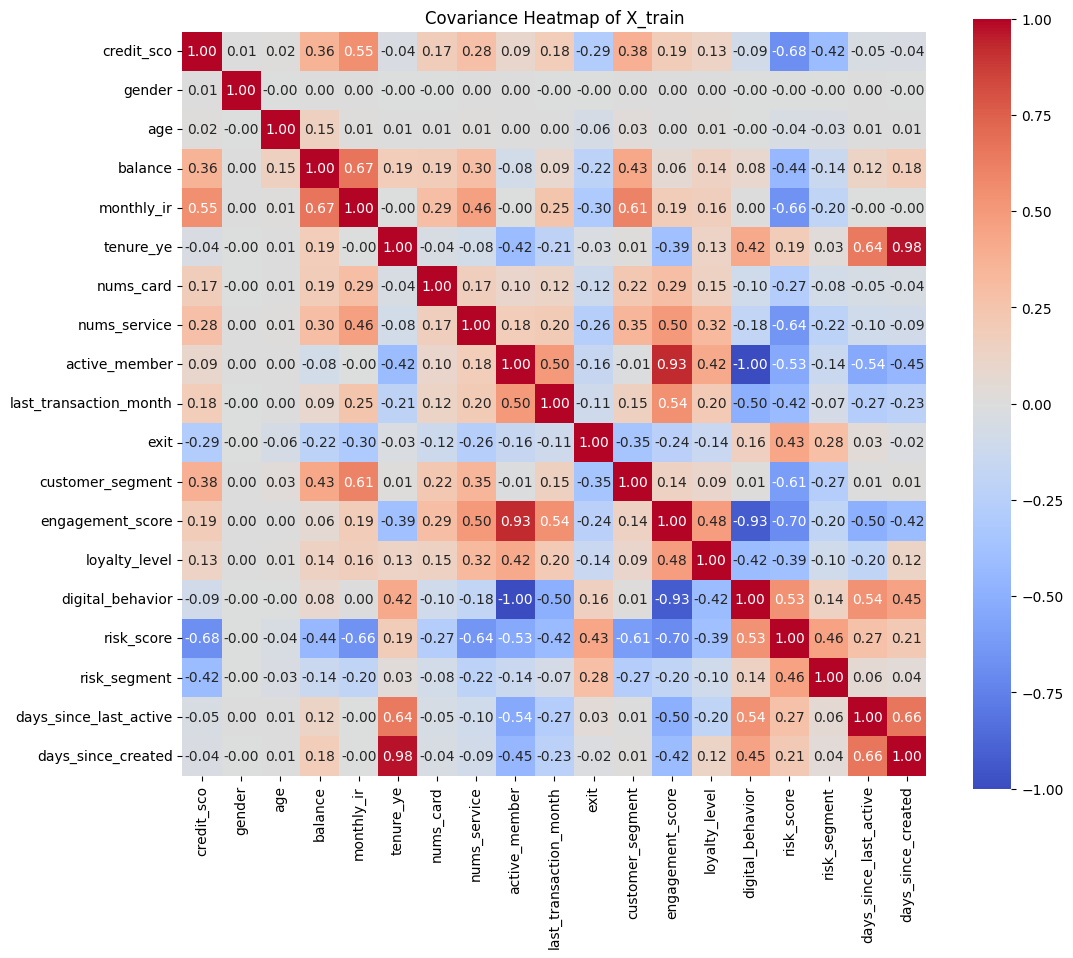

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cor_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(cor_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Covariance Heatmap of X_train')

> ## 2. Unsupervised model

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [15]:
# Standardize features
scaler = StandardScaler()
X = df.copy()
X_scale = scaler.fit_transform(X)


DETERMINING OPTIMAL CLUSTERS


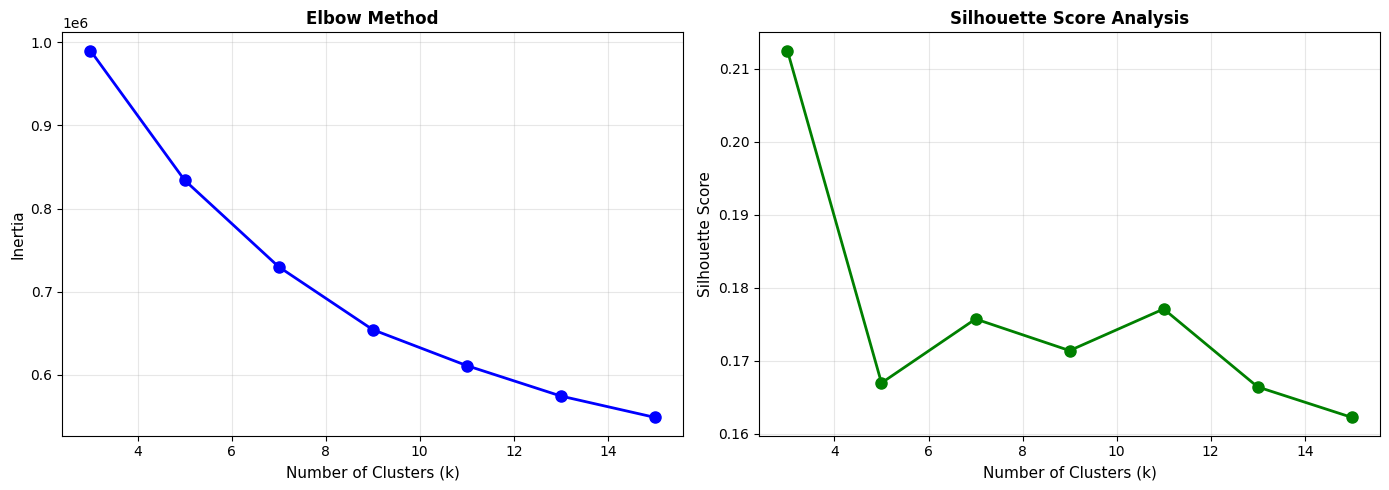


Silhouette Scores for each k:
  k=3: 0.2125
  k=5: 0.1669
  k=7: 0.1757
  k=9: 0.1714
  k=11: 0.1771
  k=13: 0.1664
  k=15: 0.1622


In [ ]:
# Determine optimal number of clusters using Elbow Method
print("\n" + "=" * 60)
print("DETERMINING OPTIMAL CLUSTERS")
print("=" * 60)

inertias = []
silhouette_scores = []
K_range = [3,5,7,9,11, 13, 15]

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    kmeans.fit(X_scale)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scale, kmeans.labels_))

# Plot Elbow Curve and Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score Analysis', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSilhouette Scores for each k:")
for k, score in zip(K_range, silhouette_scores):
    print(f"  k={k}: {score:.4f}")


FINAL K-MEANS MODEL (k=3)

Cluster distribution:
Cluster
0    21385
1    17168
2    41447
Name: count, dtype: int64

CLUSTER PROFILES

Cluster Centers (Original Scale):
         credit_sco  gender     age       balance    monthly_ir  tenure_ye  \
Cluster                                                                      
0           718.110   0.503  50.030  1.364046e+08  7.693037e+07      2.100   
1           693.198   0.504  49.380  4.723659e+07  3.759564e+07      0.729   
2           663.211   0.497  49.048  2.814886e+07  1.767216e+07      2.045   

         nums_card  nums_service  active_member  last_transaction_month  \
Cluster                                                                   
0            3.087         4.765            0.0            1.984578e+04   
1            2.859         4.265            1.0            4.112940e+07   
2            2.308         2.655            0.0            1.548780e+02   

          exit  customer_segment  engagement_score  loyalty_lev

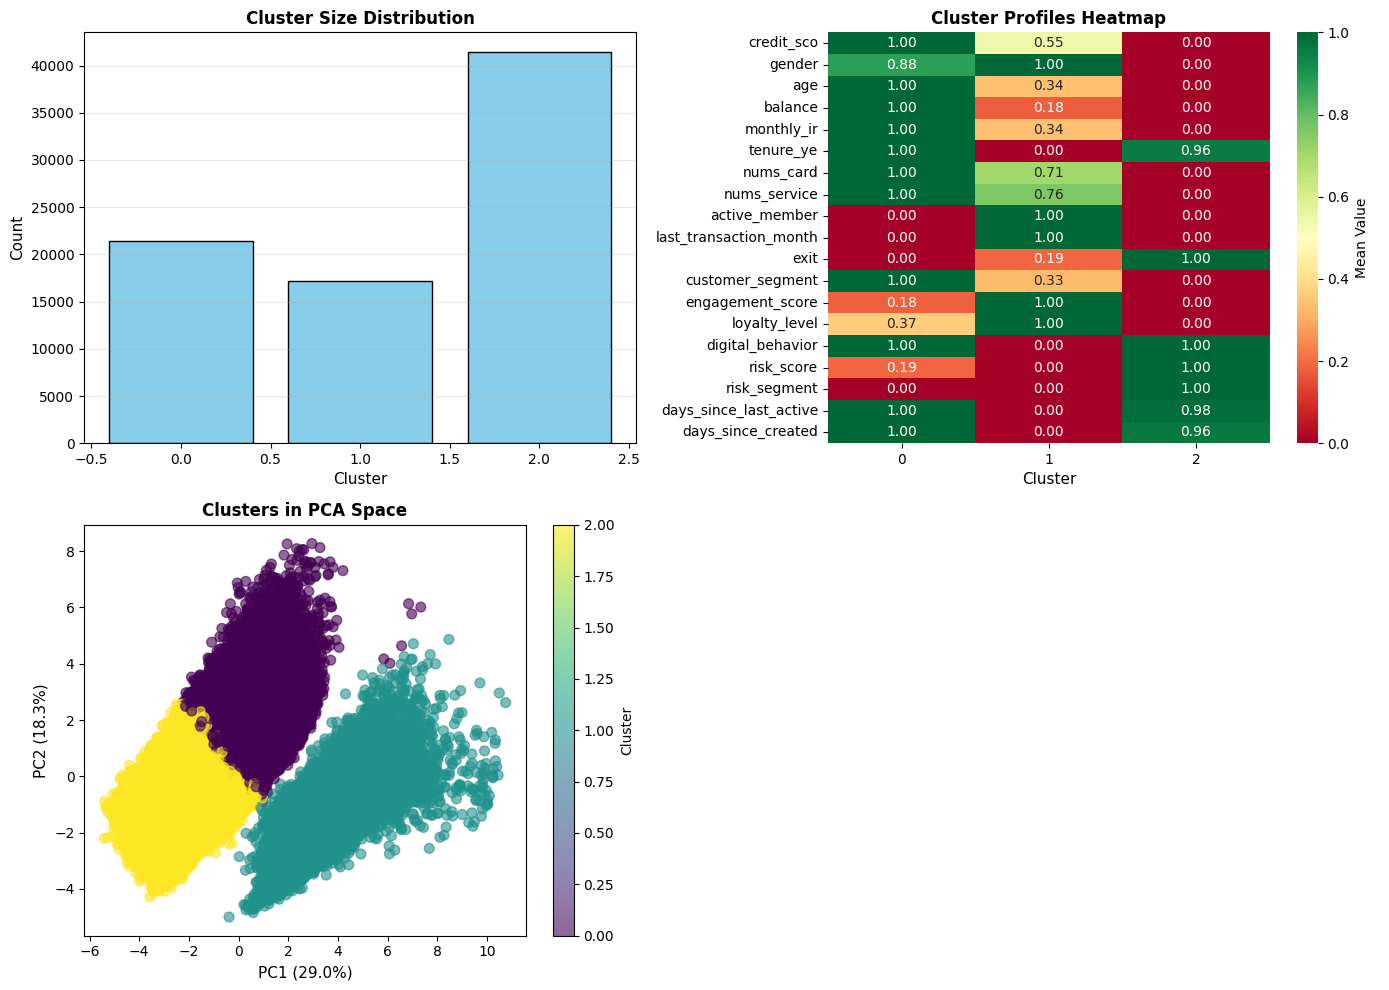

In [16]:
# Train final K-means model based on best k
optimal_k = 3  
kmeans_final = KMeans(n_clusters=optimal_k, random_state=10, n_init=10)
clusters = kmeans_final.fit_predict(X_scale)
df['Cluster'] = clusters

print(f"\n" + "=" * 60)
print(f"FINAL K-MEANS MODEL (k={optimal_k})")
print("=" * 60)
print(f"\nCluster distribution:\n{df['Cluster'].value_counts().sort_index()}")

# Cluster Profiling
print("\n" + "=" * 60)
print("CLUSTER PROFILES")
print("=" * 60)

# Get original scale statistics for interpretation
cluster_profiles = df.groupby('Cluster').mean()
profile_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

print(f"\nCluster Centers (Original Scale):")
print(cluster_profiles.round(3))

# Detailed profiling statistics
for cluster_id in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster_id]
    
    print(f"\n{'─' * 60}")
    print(f"CLUSTER {cluster_id} PROFILE")
    print(f"{'─' * 60}")
    print(f"Size: {len(cluster_data)} records ({len(cluster_data)/len(df)*100:.1f}%)")
    
    print(f"\nCharacteristics (Mean values):")
    for col in X.columns:
        mean_val = cluster_data[col].mean()
        overall_mean = df[col].mean()
        diff_pct = ((mean_val - overall_mean) / overall_mean * 100) if overall_mean != 0 else 0
        print(f"  {col:.<35} {mean_val:>10.2f} ({diff_pct:+.1f}% vs overall)")

# Visualization: Cluster distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# Plot 1: Cluster size
cluster_sizes = df['Cluster'].value_counts().sort_index()
axes[0].bar(cluster_sizes.index, cluster_sizes.values, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Heatmap of cluster profiles
sns.heatmap(profile_norm.T, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Mean Value'})
axes[1].set_title('Cluster Profiles Heatmap', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=11)

# Plot 3: PCA visualization (if applicable)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scale)
scatter = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis', s=50, alpha=0.6)
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[2].set_title('Clusters in PCA Space', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[2], label='Cluster')

axes[3].axis('off')

plt.tight_layout()
plt.savefig('cluster_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
# Save results